In [1]:
import zipfile
import os

os.makedirs("/kaggle/working/train", exist_ok=True)
os.makedirs("/kaggle/working/test", exist_ok=True)

with zipfile.ZipFile("/kaggle/input/aerial-cactus-identification/train.zip", "r") as z:
    z.extractall("/kaggle/working/train")
with zipfile.ZipFile("/kaggle/input/aerial-cactus-identification/test.zip", "r") as z:
    z.extractall("/kaggle/working/test")



In [2]:
import numpy as np
import pandas as pd
from IPython.display import Image
import matplotlib.pyplot as plt
import cv2

# FIX: avoid tf_keras/protobuf incompat issues; keep same Keras semantics via tensorflow.keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

import os

# Determinism (score-neutral; helps stability)
np.random.seed(42)
tf.random.set_seed(42)



2026-01-10 22:42:40.817518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768084960.831235      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768084960.835556      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-10 22:42:40.853860: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
# FIX: zip extracts images directly under /kaggle/working/train and /kaggle/working/test
train_directory = "/kaggle/working/train"
test_directory = "/kaggle/working/test"

assert os.path.isdir(train_directory), f"Train directory not found: {train_directory}"
assert os.path.isdir(test_directory), f"Test directory not found: {test_directory}"

# Sanity check: ensure jpgs exist
train_jpgs = [f for f in os.listdir(train_directory) if f.lower().endswith(".jpg")]
test_jpgs = [f for f in os.listdir(test_directory) if f.lower().endswith(".jpg")]
assert len(train_jpgs) > 0, "No training images found after extraction."
assert len(test_jpgs) > 0, "No test images found after extraction."

len(train_jpgs), len(test_jpgs)



(14175, 3325)

In [4]:
train_df = pd.read_csv("/kaggle/input/aerial-cactus-identification/train.csv")
train_df["id"] = train_df["id"].astype(str)
train_df["has_cactus"] = train_df["has_cactus"].astype(
    str
)  # for flow_from_dataframe binary labels
train_df.head()



,id,has_cactus
0,2de8f189f1dce439766637e75df0ee27.jpg,1
1,36704d250f236238e7f996812c48235d.jpg,1
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1
4,152491e0daf75c0e669400300ff7e645.jpg,1


In [5]:
test_df = pd.read_csv(
    "/kaggle/input/aerial-cactus-identification/sample_submission.csv"
)
test_df["id"] = test_df["id"].astype(str)
test_df.head()



,id,has_cactus
0,09034a34de0e2015a8a28dfe18f423f6.jpg,0.5
1,134f04305c795d6d202502c2ce3578f3.jpg,0.5
2,41fad8d145e6c41868ce3617e30a2545.jpg,0.5
3,35f8a11352c8d41b6231bb33d8d09f7e.jpg,0.5
4,b77dc902b035887cbbc01920ce0e3151.jpg,0.5


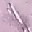

In [6]:
# (Display is optional; keep but ensure file exists)
img_path = os.path.join(train_directory, train_df.iloc[0, 0])
assert os.path.isfile(img_path), f"Missing example image: {img_path}"
Image(img_path, width=32, height=32)



In [7]:
main_datagenerator = ImageDataGenerator(rescale=1.0 / 255.0)



In [8]:
# FIX: make a real train/val split with non-empty val that contains both classes.
# Keep core approach (ImageDataGenerator + flow_from_dataframe); just correct the split logic.
split_idx = int(len(train_df) * 0.9)
train_part = train_df.iloc[:split_idx].copy()
val_part = train_df.iloc[split_idx:].copy()

# Ensure both classes exist in val; if not, reshuffle deterministically and retry once.
if val_part["has_cactus"].nunique() < 2:
    train_df_shuffled = train_df.sample(frac=1.0, random_state=42).reset_index(
        drop=True
    )
    split_idx = int(len(train_df_shuffled) * 0.9)
    train_part = train_df_shuffled.iloc[:split_idx].copy()
    val_part = train_df_shuffled.iloc[split_idx:].copy()

assert (
    train_part["has_cactus"].nunique() == 2
), "Train split does not contain both classes."
assert (
    val_part["has_cactus"].nunique() == 2
), "Validation split does not contain both classes."

train_data_batch_size = 150
train_datagenerator = main_datagenerator.flow_from_dataframe(
    dataframe=train_part,
    directory=train_directory,
    x_col="id",
    y_col="has_cactus",
    class_mode="binary",
    target_size=(32, 32),
    batch_size=train_data_batch_size,
    shuffle=True,
    seed=42,
)

val_data_batch_size = 20
val_datagenerator = main_datagenerator.flow_from_dataframe(
    dataframe=val_part,
    directory=train_directory,
    x_col="id",
    y_col="has_cactus",
    class_mode="binary",
    target_size=(32, 32),
    batch_size=val_data_batch_size,
    shuffle=False,
)

(
    len(train_part),
    len(val_part),
    train_part["has_cactus"].value_counts().to_dict(),
    val_part["has_cactus"].value_counts().to_dict(),
)



Found 12757 validated image filenames belonging to 2 classes.
Found 1418 validated image filenames belonging to 2 classes.


(12757, 1418, {'1': 9566, '0': 3191}, {'1': 1062, '0': 356})

In [9]:
for data, labels in train_datagenerator:
    print("data-shape: ", data.shape)
    print("label-shape: ", labels.shape)
    break  # dont want to see the whole generating shapes



data-shape:  (150, 32, 32, 3)
label-shape:  (150,)


In [10]:
model = models.Sequential()
model.add(
    Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=(32, 32, 3))
)
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model.add(MaxPool2D((2, 2)))
model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dense(128, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.summary()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-10 22:42:47.903690: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768084967.904432      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 569,281 (2.17 MB)

 Trainable params: 569,281 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=["acc"],
)



In [12]:
number_of_epochs = 10  # keep original
steps = 30  # keep original

history = model.fit(
    train_datagenerator,
    steps_per_epoch=steps,
    epochs=number_of_epochs,
    validation_data=val_datagenerator,
    validation_steps=min(20, len(val_datagenerator)),
    verbose=1,
)



Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1768084969.208700      65 service.cc:148] XLA service 0x7f3f8800b3d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768084969.208728      65 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-10 22:42:49.236435: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768084969.354139      65 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-01-10 22:42:49.914198: I external/local_xla/xla/stream_executor

 9/30 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.7408 - loss: 0.6174

I0000 00:00:1768084973.607278      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - acc: 0.7473 - loss: 0.5758 - val_acc: 0.7550 - val_loss: 0.5237
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - acc: 0.7659 - loss: 0.4984 - val_acc: 0.7550 - val_loss: 0.4751
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.7631 - loss: 0.4434 - val_acc: 0.8100 - val_loss: 0.3795
Epoch 4/10
 4/30 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.7946 - loss: 0.3938

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.8260 - loss: 0.3758 - val_acc: 0.8550 - val_loss: 0.2926
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.8933 - loss: 0.2985 - val_acc: 0.9300 - val_loss: 0.2306
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9083 - loss: 0.2420 - val_acc: 0.9350 - val_loss: 0.2043
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9275 - loss: 0.2121 - val_acc: 0.9075 - val_loss: 0.2446
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - acc: 0.9093 - loss: 0.2333 - val_acc: 0.8625 - val_loss: 0.2789
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9226 - loss: 0.2104 - val_acc: 0.9450 - val_loss: 0.1622
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9253 - loss: 0.1970 - val_acc: 0.9450 - val_loss: 0.1594


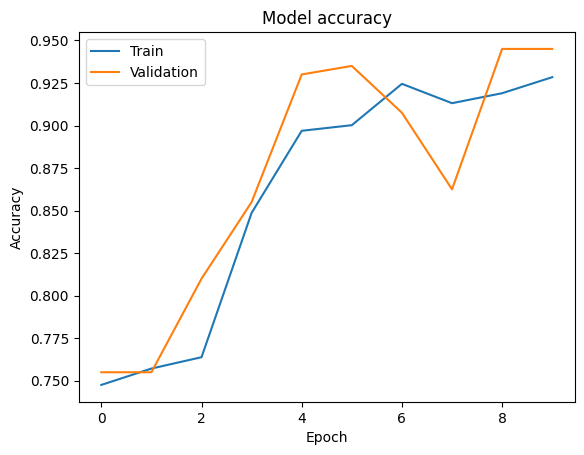

In [13]:
plt.plot(history.history["acc"])
plt.plot(history.history["val_acc"])
plt.title("Model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()



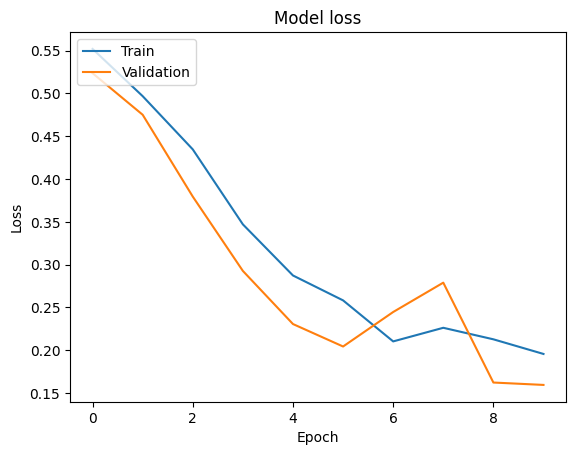

In [14]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()



In [15]:
# FIX: flow_from_directory expects subfolders; create a temporary "test" class folder with symlinks/copies.
# This keeps the same generator-based inference logic and ensures non-empty Sequence.
import shutil

test_root = "/kaggle/working/test_for_generator"
test_class_dir = os.path.join(test_root, "test")
os.makedirs(test_class_dir, exist_ok=True)

# Populate with symlinks if possible; fallback to copy (still small dataset).
# Only do once to keep runtime bounded.
existing = [f for f in os.listdir(test_class_dir) if f.lower().endswith(".jpg")]
if len(existing) != len(test_jpgs):
    # clear any partial contents
    for f in os.listdir(test_class_dir):
        fp = os.path.join(test_class_dir, f)
        try:
            os.remove(fp)
        except OSError:
            pass
    for fn in test_jpgs:
        src = os.path.join(test_directory, fn)
        dst = os.path.join(test_class_dir, fn)
        try:
            os.symlink(src, dst)
        except OSError:
            shutil.copy2(src, dst)

test_generator = main_datagenerator.flow_from_directory(
    directory=test_root,
    target_size=(32, 32),
    batch_size=32,
    class_mode=None,
    shuffle=False,
)

len(test_generator), test_generator.samples



Found 3325 images belonging to 1 classes.


(104, 3325)

In [16]:
prediction = model.predict(test_generator, verbose=1)
pred_proba = prediction.reshape(-1)

print("Predictions shape:", pred_proba.shape)
print("Pred proba min/max:", float(pred_proba.min()), float(pred_proba.max()))



104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
Predictions shape: (3325,)
Pred proba min/max: 0.0196420568972826 0.9999915361404419


In [17]:
test_files = test_df["id"].tolist()
len(test_files), test_files[:5]



(3325,
 ['09034a34de0e2015a8a28dfe18f423f6.jpg',
  '134f04305c795d6d202502c2ce3578f3.jpg',
  '41fad8d145e6c41868ce3617e30a2545.jpg',
  '35f8a11352c8d41b6231bb33d8d09f7e.jpg',
  'b77dc902b035887cbbc01920ce0e3151.jpg'])

In [18]:
# flow_from_directory stores filenames relative to directory, like "test/xxx.jpg"
gen_filenames = [os.path.basename(f) for f in test_generator.filenames]
assert len(gen_filenames) == len(
    pred_proba
), "Mismatch between generated filenames and predictions."

pred_map = dict(zip(gen_filenames, pred_proba))
missing = [i for i in test_files if i not in pred_map]
assert (
    len(missing) == 0
), f"Missing predictions for {len(missing)} test ids, e.g. {missing[:3]}"

ordered_pred = np.array([pred_map[i] for i in test_files], dtype=np.float32)
sub_file = pd.DataFrame({"id": test_files, "has_cactus": ordered_pred})
sub_file.head()



,id,has_cactus
0,09034a34de0e2015a8a28dfe18f423f6.jpg,0.467030
1,134f04305c795d6d202502c2ce3578f3.jpg,0.975313
2,41fad8d145e6c41868ce3617e30a2545.jpg,0.991504
3,35f8a11352c8d41b6231bb33d8d09f7e.jpg,0.919706
4,b77dc902b035887cbbc01920ce0e3151.jpg,0.997026


In [19]:
sub_path = "submission.csv"
sub_file.to_csv(sub_path, index=False)
print("Wrote:", sub_path, "rows:", len(sub_file))
print(sub_file.describe(include="all"))



Wrote: submission.csv rows: 3325
                                          id   has_cactus
count                                   3325  3325.000000
unique                                  3325          NaN
top     09034a34de0e2015a8a28dfe18f423f6.jpg          NaN
freq                                       1          NaN
mean                                     NaN     0.724351
std                                      NaN     0.359977
min                                      NaN     0.019642
25%                                      NaN     0.450754
50%                                      NaN     0.940682
75%                                      NaN     0.991233
max                                      NaN     0.999992


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [20]:
import shutil

# Cleanup temp generator dir and extracted zips to save disk (score-neutral)
if os.path.isdir("/kaggle/working/test_for_generator"):
    shutil.rmtree("/kaggle/working/test_for_generator")
if os.path.isdir("/kaggle/working/test"):
    shutil.rmtree("/kaggle/working/test")
if os.path.isdir("/kaggle/working/train"):
    shutil.rmtree("/kaggle/working/train")